Imports and dataset load

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

plt.style.use("ggplot")

In [2]:
import json

train_path = r"C:\Users\Moetez\OneDrive\ml_tutor_project\data\qrecc_train.json"

with open(train_path, "r", encoding="utf-8") as f:
    train_data = json.load(f)

print("Number of samples:", len(train_data))

Number of samples: 63501


In [3]:
sample = train_data[0]

print(sample.keys())

dict_keys(['Context', 'Question', 'Rewrite', 'Answer', 'Answer_URL', 'Conversation_no', 'Turn_no', 'Conversation_source'])


In [4]:
sample

{'Context': [],
 'Question': 'What can you tell me about Gary Cherone?',
 'Rewrite': 'What can you tell me about Gary Cherone?',
 'Answer': 'Gary Francis Caine Cherone is an American rock singer and songwriter, known for his work as the lead vocalist of Extreme and for his short stint for Van Halen.',
 'Answer_URL': 'https://en.wikipedia.org/wiki/Van_Halen',
 'Conversation_no': 1,
 'Turn_no': 1,
 'Conversation_source': 'quac'}

Convert to dataframe

In [5]:
df = pd.DataFrame(train_data)

df.head()

,Context,Question,Rewrite,Answer,Answer_URL,Conversation_no,Turn_no,Conversation_source
0,[],What can you tell me about Gary Cherone?,What can you tell me about Gary Cherone?,Gary Francis Caine Cherone is an American rock...,https://en.wikipedia.org/wiki/Van_Halen,1,1,quac
1,"[What can you tell me about Gary Cherone?, Gar...",Did Gary sing well?,Did Gary Cherone sing well?,"Yes, Gary Cherone is also known for his work a...",https://en.wikipedia.org/wiki/Van_Halen,1,2,quac
2,"[What can you tell me about Gary Cherone?, Gar...",What significant fact can you tell me about Ga...,What significant fact can you tell me about Ga...,I like that Gary Cherone remained in contact a...,https://en.wikipedia.org/wiki/Van_Halen,1,3,quac
3,"[What can you tell me about Gary Cherone?, Gar...",What did Cherone do after Van Halen?,What did Gary Cherone do after Van Halen?,"After his departure from Van Halen, Gary Chero...",https://en.wikipedia.org/wiki/Van_Halen,1,4,quac
4,"[What can you tell me about Gary Cherone?, Gar...",Did they release any albums during that time f...,Did they release any albums after Gary Cherone...,"After Gary Cherone, Eddie Van Halen recovered ...",https://en.wikipedia.org/wiki/Van_Halen,1,5,quac


In [6]:
df.columns

Index(['Context', 'Question', 'Rewrite', 'Answer', 'Answer_URL',
       'Conversation_no', 'Turn_no', 'Conversation_source'],
      dtype='str')

Exploratory Data Analysis

In [7]:
print("Unique conversations:", df["Conversation_no"].nunique())

Unique conversations: 10823


In [8]:
turn_counts = df.groupby("Conversation_no")["Turn_no"].max()

print("Average turns:", turn_counts.mean())

Average turns: 6.00822322831008


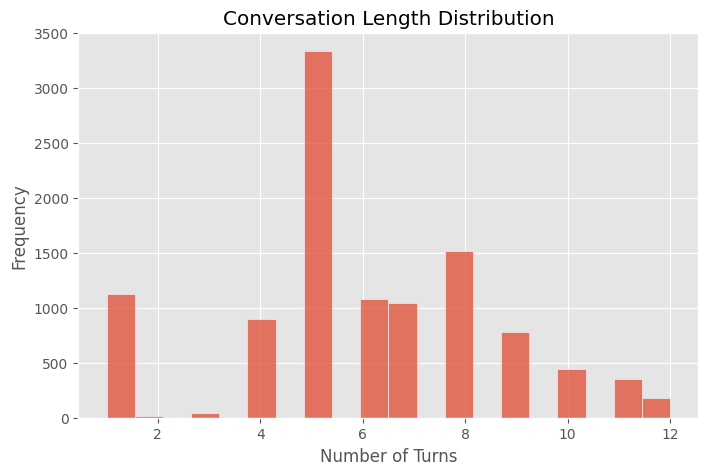

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(turn_counts, bins=20)

plt.title("Conversation Length Distribution")
plt.xlabel("Number of Turns")
plt.ylabel("Frequency")

plt.show()

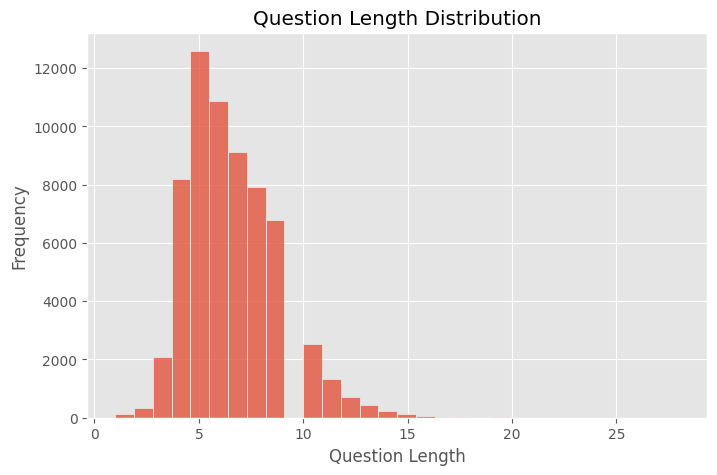

In [10]:
df["question_length"] = df["Question"].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(8,5))

sns.histplot(df["question_length"], bins=30)

plt.title("Question Length Distribution")
plt.xlabel("Question Length")
plt.ylabel("Frequency")

plt.show()

Compare original Vs. rewritten questions

In [11]:
for i in range(5):

    print("="*80)

    print("ORIGINAL QUESTION:")
    print(df.iloc[i]["Question"])

    print("\nREWRITTEN QUESTION:")
    print(df.iloc[i]["Rewrite"])

ORIGINAL QUESTION:
What can you tell me about Gary Cherone?

REWRITTEN QUESTION:
What can you tell me about Gary Cherone?
ORIGINAL QUESTION:
Did Gary sing well?

REWRITTEN QUESTION:
Did Gary Cherone sing well?
ORIGINAL QUESTION:
What significant fact can you tell me about Gary that you liked?

REWRITTEN QUESTION:
What significant fact can you tell me about Gary Cherone that you liked?
ORIGINAL QUESTION:
What did Cherone do after Van Halen?

REWRITTEN QUESTION:
What did Gary Cherone do after Van Halen?
ORIGINAL QUESTION:
Did they release any albums during that time frame?

REWRITTEN QUESTION:
Did they release any albums after Gary Cherone left?


Ambiguous questions detection

In [12]:
ambiguous_patterns = [
    "why?",
    "what about",
    "what happened next",
    "can you explain",
    "how so",
    "what do you mean",
    "why did that happen",
    "and then",
    "why"
]

In [13]:
def is_ambiguous(question):

    q = str(question).lower()

    return any(pattern in q for pattern in ambiguous_patterns)

df["is_ambiguous"] = df["Question"].apply(is_ambiguous)

df["is_ambiguous"].value_counts()

is_ambiguous
False    61478
True      2023
Name: count, dtype: int64

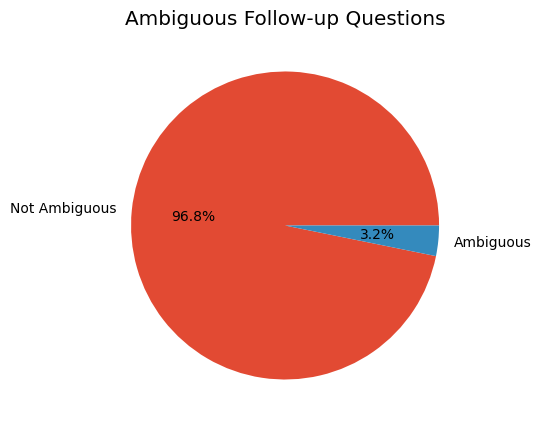

In [14]:
amb_counts = df["is_ambiguous"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    amb_counts,
    labels=["Not Ambiguous", "Ambiguous"],
    autopct="%1.1f%%"
)

plt.title("Ambiguous Follow-up Questions")

plt.show()

Confusion signal detection

In [15]:
confusion_keywords = [
    "don't understand",
    "confused",
    "simplify",
    "explain again",
    "not clear",
    "i still don't get it",
    "what do you mean",
    "can you simplify"
]

In [16]:
def detect_confusion(question):

    q = str(question).lower()

    return any(k in q for k in confusion_keywords)

df["confusion_signal"] = df["Question"].apply(
    detect_confusion
)

df["confusion_signal"].value_counts()

confusion_signal
False    63495
True         6
Name: count, dtype: int64

In [17]:
confused_samples = df[df["confusion_signal"] == True]

confused_samples[
    ["Question", "Rewrite"]
].head(10)

,Question,Rewrite
7512,What do you mean by prefigured?,What do you mean by The Sweet prefigured?
23813,What do you mean by diatonic?,What does diatonic music mean?
32203,What do you mean by non-city?,What do you mean by non-city within Rem Koolha...
33120,What do you mean by that?,What do you mean by Ted Shapiro becoming part ...
34310,What do you mean by non-city?,What do you mean being regarded as non-cities?
48317,What do you mean turned away?,What does it mean when Roberto Mangabeira Unge...


In [18]:
df.to_csv(r"C:\Users\Moetez\OneDrive\ml_tutor_project\data\qrecc_processed.csv", index=False)

# Key Observations

1. Many questions are context-dependent.

2. Rewritten questions significantly improve clarity.

3. Short questions often rely heavily on conversation history.

4. Conversations contain ambiguity patterns.

5. Clarification and confusion signals naturally appear.

6. Long conversations justify memory compression methods.